<a href="https://www.kaggle.com/code/spatola/ml-in-practice-assignment?scriptVersionId=241608081" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction
This notebook intends to understand the data in the birdCLEF_2025 dataset and create some simple classifire models for recognizing species by ther soud.

In [141]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from IPython.display import Audio
from sklearn.metrics import roc_curve

In [142]:
# Load data
INPUT_PATH = '/kaggle/input/birdclef-2025/'
TRAIN_AUDIO_PATH = os.path.join(INPUT_PATH, 'train_audio')
TEST_SOUNDSCAPES_PATH = os.path.join(INPUT_PATH, 'test_soundscapes')
TRAIN_SOUNDSCAPES_PATH = os.path.join(INPUT_PATH, 'train_soundscapes')

# Load data
taxonomy = pd.read_csv(os.path.join(INPUT_PATH, 'taxonomy.csv'))
train_meta = pd.read_csv(os.path.join(INPUT_PATH, 'train.csv'))
# recording_locations = pd.read_csv(os.path.join(INPUT_PATH, 'recording_location.txt'))

## Understanding our data

In [143]:
train_meta.head()

,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0


In [144]:
# link the filenames to our dataset
def preprocess_train_meta(df):
    """Preprocesses the training metadata."""
    df['secondary_labels'] = df['secondary_labels'].apply(lambda x: re.findall(r"'(\w+)'", x))
    df['file_path'] = df.apply(lambda row: os.path.join(TRAIN_AUDIO_PATH, row['filename']), axis=1)
    return df

train_meta = preprocess_train_meta(train_meta)
train_meta.dtypes
train_meta.head()


,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license,file_path
0,1139490,[],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0,/kaggle/input/birdclef-2025/train_audio/113949...
1,1139490,[],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0,/kaggle/input/birdclef-2025/train_audio/113949...
2,1192948,[],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,/kaggle/input/birdclef-2025/train_audio/119294...
3,1192948,[],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,/kaggle/input/birdclef-2025/train_audio/119294...
4,1192948,[],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0,/kaggle/input/birdclef-2025/train_audio/119294...


In [145]:
taxonomy.head() # we see that taxonomy allow us to match 'primarry_lables' of train.csv to the species


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1139490,1139490,Ragoniella pulchella,Ragoniella pulchella,Insecta
1,1192948,1192948,Oxyprora surinamensis,Oxyprora surinamensis,Insecta
2,1194042,1194042,Copiphora colombiae,Copiphora colombiae,Insecta
3,126247,126247,Leptodactylus insularum,Spotted Foam-nest Frog,Amphibia
4,1346504,1346504,Neoconocephalus brachypterus,Neoconocephalus brachypterus,Insecta


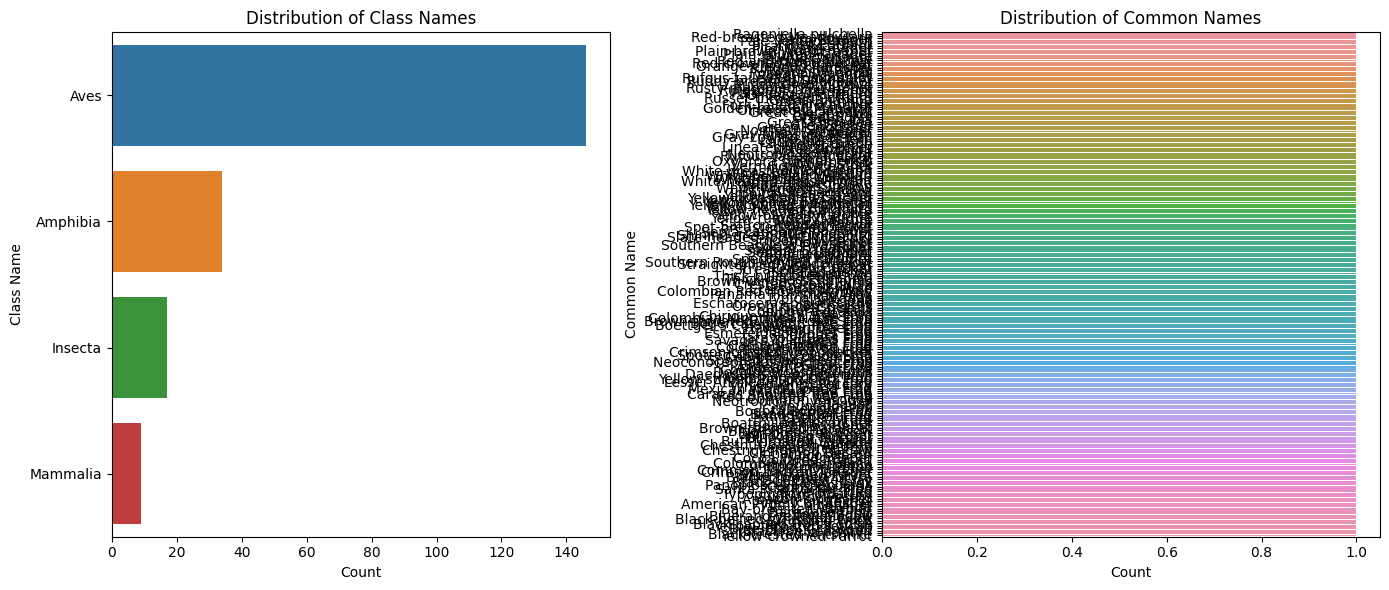

Are 'class_name' and 'common_name' identical? False


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1139490,1139490,Ragoniella pulchella,Ragoniella pulchella,Insecta
1,1192948,1192948,Oxyprora surinamensis,Oxyprora surinamensis,Insecta
2,1194042,1194042,Copiphora colombiae,Copiphora colombiae,Insecta
3,126247,126247,Leptodactylus insularum,Spotted Foam-nest Frog,Amphibia
4,1346504,1346504,Neoconocephalus brachypterus,Neoconocephalus brachypterus,Insecta
...,...,...,...,...,...
201,yehcar1,1432779,Milvago chimachima,Yellow-headed Caracara,Aves
202,yelori1,9352,Icterus nigrogularis,Yellow Oriole,Aves
203,yeofly1,16567,Tolmomyias sulphurescens,Yellow-olive Flycatcher,Aves
204,yercac1,10359,Cacicus cela,Yellow-rumped Cacique,Aves


In [146]:

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=taxonomy, y='class_name', order=taxonomy['class_name'].value_counts().index)
plt.title('Distribution of Class Names')
plt.xlabel('Count')
plt.ylabel('Class Name')

plt.subplot(1, 2, 2)
sns.countplot(data=taxonomy, y='common_name', order=taxonomy['common_name'].value_counts().index)
plt.title('Distribution of Common Names')
plt.xlabel('Count')
plt.ylabel('Common Name')

plt.tight_layout()
plt.show()

# Check if the two columns are identical
identical = taxonomy['inat_taxon_id'].equals(taxonomy['primary_label'])
print(f"Are 'class_name' and 'common_name' identical? {identical}")

# Show rows where they differ, if any
diff_rows = taxonomy[taxonomy['class_name'] != taxonomy['common_name']]
diff_rows

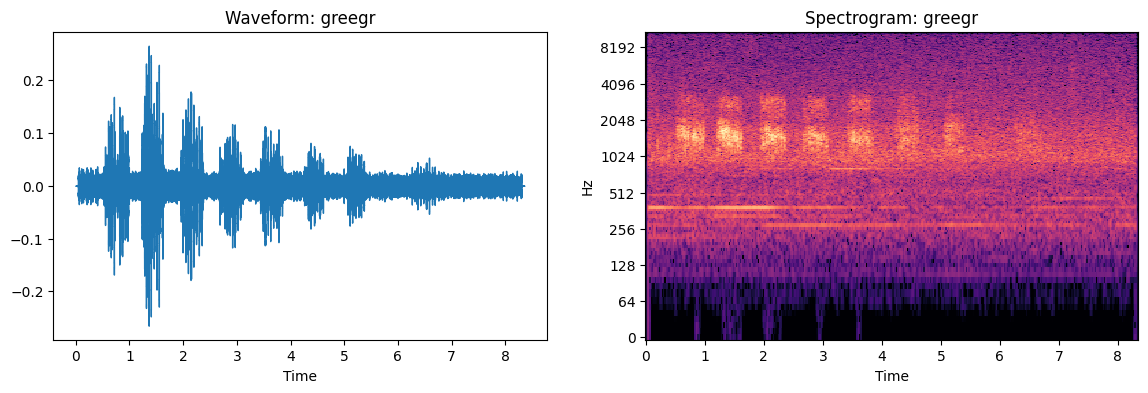

In [147]:
# lets explore an audio file
audio_examples = train_meta.sample(1)
file_path = audio_examples['file_path'].tolist()[0]
title = audio_examples['primary_label'].tolist()[0]


Audio(file_path)
y, sr = librosa.load(file_path)
# Plot waveform
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform: " + title )

# Plot spectrogram
plt.subplot(1, 2, 2)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.title(f'Spectrogram: {title}')
plt.show()

## Feature extraction
based on [1] and [2] we decidet to use Mel-Frequency Cepstral Coefficients (MFCCs) to train our model

In [149]:
# Feature Extraction (Simple MFCC)
def extract_mfcc(file_path, sr=22050, n_mfcc=20):
    """Extracts MFCC features from an audio file."""
    try:
        y, sr = librosa.load(file_path, sr=sr)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_processed = np.mean(mfccs.T, axis=0)  # Average across time
    except Exception as e:
        # Comment out this line to suppress error messages
        # print(f"Error processing {file_path}: {e}")
        return None
    return mfccs_processed

# Example MFCC extraction
example_file = train_meta['file_path'].iloc[0]
mfccs = extract_mfcc(example_file)
print("\nMFCC Features Example:", mfccs)




MFCC Features Example: [-3.0088031e+02  1.0080162e+02  2.0586250e+01  2.5397343e+01
  1.5968860e+01  1.1692366e+01 -2.5268309e+00  3.2565429e+00
  4.2799884e-01  8.4082156e-01 -5.5912833e+00  4.9153862e+00
 -2.2406311e-01 -2.1817577e+00 -2.5627687e+00  5.9108195e+00
 -4.9044609e+00  1.4878420e+00  1.3020750e+00 -1.0821764e+00]


## Train Models
- SVM
- gradiant boosting
- 

In [ ]:
# Model Training (XGBoost or LightGBM)
def train_model(train_meta, model_type='xgboost', n_samples=500, n_mfcc=20):
    """Trains a XGBoost or LightGBM model."""
    # Sample a subset of data for faster training
    train_subset = train_meta.sample(n_samples, random_state=42)

    # Extract MFCC features
    features = []
    labels = []
    for index, row in train_subset.iterrows():
        mfccs = extract_mfcc(row['file_path'], n_mfcc=n_mfcc)
        if mfccs is not None:
            features.append(mfccs)
            labels.append(row['primary_label'])

    X = np.array(features)
    y = np.array(labels)

    # Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


    if model_type == 'xgboost':
        model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) #added eval_metric as it is needed
        model.fit(X_train, y_train)

    elif model_type == 'lightgbm':
        model = lgb.LGBMClassifier(random_state=42)
        model.fit(X_train, y_train)

    else:
        raise ValueError("Invalid model_type. Choose 'xgboost' or 'lightgbm'.")

    return model, X_test, y_test, y_train

#Choose between 'xgboost' or 'lightgbm'
model, X_test, y_test, y_train = train_model(train_meta, model_type='lightgbm') #or 'xgboost'

In [ ]:
# model evaluations

fpr, tpr, thresholds = roc_curve(y_true, y_score)


Sources:
- https://www.kaggle.com/code/jocelyndumlao/birdclef-2025-mfcc-feature-roc-auc-analysis#Import-Libraries (24.05.2025)
- https://github.com/UtrechtUniversity/animal-sounds (24.05.2025)